In [2]:
from extraccion import minioFunctions as mf
import limpieza as lp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RUSIA

In [24]:
l = []
for k in [0,1]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Nuevas_Zonas/rusia{k}.parquet", type="df")
    l.append(dataf)

probar = pd.concat(l, ignore_index=True)

Analizando el año 0:
Dataframe importado correctamente
Analizando el año 1:
Dataframe importado correctamente


In [25]:
probar.info()

<class 'pandas.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 2704 non-null   float64       
 1   lon                 2704 non-null   float64       
 2   date                2704 non-null   datetime64[us]
 3   final               2704 non-null   int64         
 4   temp_mean           2699 non-null   float64       
 5   temp_max            2699 non-null   float64       
 6   temp_min            2699 non-null   float64       
 7   humidity_mean       2699 non-null   float64       
 8   precipitation       2699 non-null   float64       
 9   wind_speed_max      2699 non-null   float64       
 10  wind_gusts_max      2699 non-null   float64       
 11  pressure_mean       2699 non-null   float64       
 12  cloud_cover         2699 non-null   float64       
 13  radiation           2699 non-null   float64       
 14  eva

Se han realizado nuevas extracciones para los 2 datos nulos de la temperatura del suelo.

In [26]:
df = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/rusia.parquet')
df.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 2704 non-null   float64       
 1   lon                 2704 non-null   float64       
 2   date                2704 non-null   datetime64[us]
 3   final               2704 non-null   int64         
 4   temp_mean           2699 non-null   float64       
 5   temp_max            2699 non-null   float64       
 6   temp_min            2699 non-null   float64       
 7   humidity_mean       2699 non-null   float64       
 8   precipitation       2699 non-null   float64       
 9   wind_speed_max      2699 non-null   float64       
 10  wind_gusts_max      2699 non-null   float64       
 11  pressure_mean       2699 non-null   float64       
 12  cloud_cover         2699 non-null   float64       
 13  radiation           2699 

In [27]:
print(f'Porcentaje de nulos: {df.isna().sum().unique().sum() / len(df) * 100:.2f} %')

Porcentaje de nulos: 3.33 %


Como son 72 nulos unicamente no hay problema en borrarlos indiscriminadamente (el 3%)

In [28]:
limpio = df.dropna(how='any')
limpio.info()

<class 'pandas.DataFrame'>
Index: 2614 entries, 0 to 2703
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 2614 non-null   float64       
 1   lon                 2614 non-null   float64       
 2   date                2614 non-null   datetime64[us]
 3   final               2614 non-null   int64         
 4   temp_mean           2614 non-null   float64       
 5   temp_max            2614 non-null   float64       
 6   temp_min            2614 non-null   float64       
 7   humidity_mean       2614 non-null   float64       
 8   precipitation       2614 non-null   float64       
 9   wind_speed_max      2614 non-null   float64       
 10  wind_gusts_max      2614 non-null   float64       
 11  pressure_mean       2614 non-null   float64       
 12  cloud_cover         2614 non-null   float64       
 13  radiation           2614 non-null   float64       
 14  evapotra

In [29]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/cleaned/Nuevas_Zonas/rusia.parquet', df=df)

Fichero subido como grupo3/cleaned/Nuevas_Zonas/rusia.parquet


# NORTE DE ÁFRICA

In [69]:
africa = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa.parquet')
africa.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 7279 entries, 0 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 7279 non-null   float64       
 1   lon                 7279 non-null   float64       
 2   date                7279 non-null   datetime64[us]
 3   elevacion_centro    6787 non-null   float64       
 4   grados              6772 non-null   float64       
 5   porcentaje          7279 non-null   float64       
 6   temp_mean           6752 non-null   float64       
 7   temp_max            6752 non-null   float64       
 8   temp_min            6752 non-null   float64       
 9   humidity_mean       6752 non-null   float64       
 10  precipitation       6752 non-null   float64       
 11  wind_speed_max      6752 non-null   float64       
 12  wind_gusts_max      6752 non-null   float64       
 13  pressure_mean       6752 

**Valores nulos:**

In [31]:
africa.isna().sum()

lat                     0
lon                     0
date                    0
elevacion_centro      492
grados                507
porcentaje              0
temp_mean             527
temp_max              527
temp_min              527
humidity_mean         527
precipitation         527
wind_speed_max        527
wind_gusts_max        527
pressure_mean         527
cloud_cover           527
radiation             527
evapotranspiration    527
sunshine_seconds      527
fire_index             94
soil_temp              94
dist_civ                0
NDVI                   21
NDWI                   21
dtype: int64

Se realiza una nueva extracción para la variable suelo:

Solo para aquellas que no tienen en el resto de variables nulos:

In [32]:
indicesSuelo= africa[africa['soil_temp'].isna()].index
nulos_suelo = df=africa.iloc[list(indicesSuelo)]
print(f"Nulos en físicas: {nulos_suelo['precipitation'].isna().sum()}")
print(f"Nulos en pendiente: {nulos_suelo['grados'].isna().sum()}")
print(f"Nulos en pendiente2: {nulos_suelo['elevacion_centro'].isna().sum()}")
print(f"Nulos en NDVI: {nulos_suelo['NDVI'].isna().sum()}")
print(f"Nulos en NDWI: {nulos_suelo['NDWI'].isna().sum()}")

indicesFisicas = africa[africa['precipitation'].isna()].index
indicesPendiente = africa[africa['grados'].isna()].index
indicesPendiente2 = africa[africa['elevacion_centro'].isna()].index
indicesNdvi= africa[africa['NDVI'].isna()].index
indicesNdwi = africa[africa['NDWI'].isna()].index

indicesSuelo = set(indicesSuelo).difference(set(indicesFisicas))
indicesSuelo = set(indicesSuelo).difference(set(indicesPendiente))
indicesSuelo = set(indicesSuelo).difference(set(indicesPendiente2))
indicesSuelo = set(indicesSuelo).difference(set(indicesNdvi))
indicesSuelo = set(indicesSuelo).difference(set(indicesNdwi))

Nulos en físicas: 11
Nulos en pendiente: 5
Nulos en pendiente2: 5
Nulos en NDVI: 1
Nulos en NDWI: 1


In [33]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa_nulos_suelo2.parquet', df=africa.iloc[list(indicesSuelo)])

Fichero subido como grupo3/raw/Nuevas_Zonas/norte_africa_nulos_suelo2.parquet


In [34]:
df = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa_nulos_suelo2.parquet')
df.isna().sum()

Dataframe importado correctamente


lat                    0
lon                    0
date                   0
elevacion_centro       0
grados                 0
porcentaje             0
temp_mean              0
temp_max               0
temp_min               0
humidity_mean          0
precipitation          0
wind_speed_max         0
wind_gusts_max         0
pressure_mean          0
cloud_cover            0
radiation              0
evapotranspiration     0
sunshine_seconds       0
fire_index            78
soil_temp             78
dist_civ               0
NDVI                   0
NDWI                   0
dtype: int64

In [79]:
sueloSinNulos = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/africa_limpioSuelo.parquet').reset_index()
sueloSinNulos.isna().sum()

Dataframe importado correctamente


lat                     0
lon                     0
date                    0
elevacion_centro      492
grados                507
porcentaje              0
temp_mean             527
temp_max              527
temp_min              527
humidity_mean         527
precipitation         527
wind_speed_max        527
wind_gusts_max        527
pressure_mean         527
cloud_cover           527
radiation             527
evapotranspiration    527
sunshine_seconds      527
fire_index             94
soil_temp              16
dist_civ                0
NDVI                   21
NDWI                   21
dtype: int64

In [80]:
sueloSinNulos = sueloSinNulos.set_index(['lat', 'lon'])
africa = africa.set_index(['lat', 'lon'])
africa['soil_temp'] = africa['soil_temp'].fillna(sueloSinNulos['soil_temp'])

africa.isna().sum()

date                    0
elevacion_centro      492
grados                507
porcentaje              0
temp_mean             527
temp_max              527
temp_min              527
humidity_mean         527
precipitation         527
wind_speed_max        527
wind_gusts_max        527
pressure_mean         527
cloud_cover           527
radiation             527
evapotranspiration    527
sunshine_seconds      527
fire_index             94
soil_temp              16
dist_civ                0
NDVI                   21
NDWI                   21
dtype: int64

In [ ]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/africa_limpioSuelo.parquet', df = africa)

Fichero subido como grupo3/raw/Nuevas_Zonas/africa_limpioSuelo.parquet


Observamos que hay alrededor de 500 valores tanto en las características físicas, como en las variables de la pendiente

**Nulos en las variables físicas:**

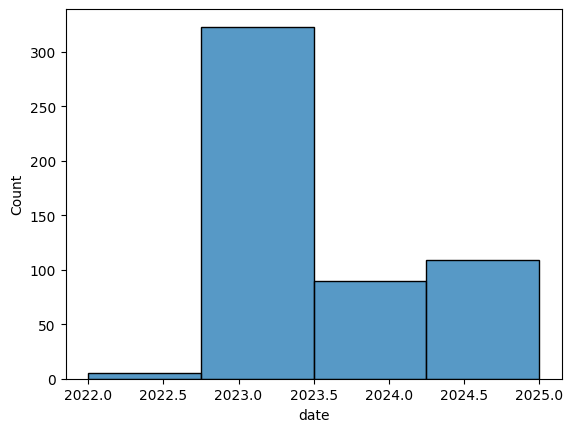

In [ ]:
indicesNulos = africa[africa['precipitation'].isna()].index
sns.histplot(x=africa['date'].iloc[indicesNulos].dt.year, bins=4)
subir = africa.iloc[indicesNulos]
# mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa_nulos.parquet')

<Axes: xlabel='date', ylabel='Count'>

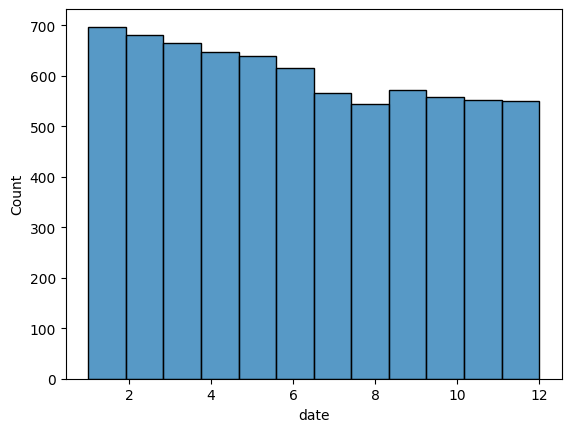

In [ ]:
sns.histplot(africa['date'].dt.month, bins=12)

**Nulos en la pendiente:**

<Axes: xlabel='date', ylabel='Count'>

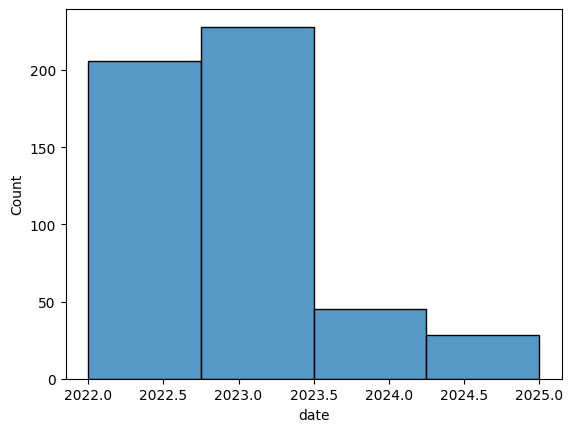

In [ ]:
indicesNull = africa[africa['grados'].isna()].index
sns.histplot(x=africa['date'].iloc[indicesNull].dt.year, bins=4)
# subir = africa.iloc[indicesNulos]

Se intentarán subsanar los valores nulos realizando las extracciones que podamos de nuevo, por si ha habido algún error, al resultarnos extraño que haya tantos valores nulos en un dataset de unas 7000 filas.

In [ ]:
#africa['date'] = africa['date'].dt.strftime("%Y-%m-%d %H:%M:%S")

**Pendiente:**

In [ ]:
# mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa_nulos_pendiente.parquet', df=africa.iloc[list(indicesNull)])

**Físicas que no están en pendiente:**

In [ ]:
indicesTodos = set(indicesNulos).difference(set(indicesNull))
len(indicesTodos)
# africa.iloc[list(indicesTodos)].info()
# mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/norte_africa_nulos.parquet', df=africa.iloc[list(indicesTodos)])

500

Se han realizado las extracciones de esos datos, y hemos conseguido subsanar todos menos un valor.

In [81]:
aniadir = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Fisicas/africa.parquet')
aniadir.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lat                 500 non-null    float64
 1   lon                 500 non-null    float64
 2   date                500 non-null    str    
 3   temp_mean           499 non-null    float64
 4   temp_max            499 non-null    float64
 5   temp_min            499 non-null    float64
 6   humidity_mean       499 non-null    float64
 7   precipitation       499 non-null    float64
 8   wind_speed_max      499 non-null    float64
 9   wind_gusts_max      499 non-null    float64
 10  pressure_mean       499 non-null    float64
 11  cloud_cover         499 non-null    float64
 12  radiation           499 non-null    float64
 13  evapotranspiration  499 non-null    float64
 14  sunshine_seconds    499 non-null    float64
dtypes: float64(14), str(1)
memory usag

In [82]:
aniadir = aniadir.dropna()

In [85]:
africa['date'] = pd.to_datetime(africa['date'])
aniadir['date'] = pd.to_datetime(aniadir['date'])
africa = africa.reset_index()

In [86]:
lats = aniadir['lat'].tolist()
lons = aniadir['lon'].tolist()
fechas = aniadir['date'].tolist()
df_filtrado = africa[~((africa['lat'].isin(lats)) & (africa['lon'].isin(lons)) & (africa['date'].isin(fechas)))]
df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 6780 entries, 0 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 6780 non-null   float64       
 1   lon                 6780 non-null   float64       
 2   date                6780 non-null   datetime64[us]
 3   elevacion_centro    6288 non-null   float64       
 4   grados              6273 non-null   float64       
 5   porcentaje          6780 non-null   float64       
 6   temp_mean           6752 non-null   float64       
 7   temp_max            6752 non-null   float64       
 8   temp_min            6752 non-null   float64       
 9   humidity_mean       6752 non-null   float64       
 10  precipitation       6752 non-null   float64       
 11  wind_speed_max      6752 non-null   float64       
 12  wind_gusts_max      6752 non-null   float64       
 13  pressure_mean       6752 non-null   float64       
 14  cloud_co

In [62]:
final = pd.concat([aniadir, df_filtrado], ignore_index=True)
final.info()

<class 'pandas.DataFrame'>
RangeIndex: 7279 entries, 0 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 7279 non-null   float64       
 1   lon                 7279 non-null   float64       
 2   date                7279 non-null   datetime64[us]
 3   temp_mean           7251 non-null   float64       
 4   temp_max            7251 non-null   float64       
 5   temp_min            7251 non-null   float64       
 6   humidity_mean       7251 non-null   float64       
 7   precipitation       7251 non-null   float64       
 8   wind_speed_max      7251 non-null   float64       
 9   wind_gusts_max      7251 non-null   float64       
 10  pressure_mean       7251 non-null   float64       
 11  cloud_cover         7251 non-null   float64       
 12  radiation           7251 non-null   float64       
 13  evapotranspiration  7251 non-null   float64       
 14  sun

In [ ]:
nulosPendiente = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Pendiente/norteAfrica_nulos.parquet')
nulosPendiente.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   lat               507 non-null    float64       
 1   lon               507 non-null    float64       
 2   date              507 non-null    datetime64[us]
 3   elevacion_centro  15 non-null     float64       
 4   grados            0 non-null      object        
 5   porcentaje        507 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(1), object(1)
memory usage: 23.9+ KB


In [54]:
subir = africa[africa['soil_temp'].isna()]
print('Numero de elementos que coinciden con pendiente (irrecuperables):', len(indicesNull.intersection(set(subir.index))))
print(f'Porcentaje de nulos en suelo: {len(subir) / len(africa) * 100:.2f} %')
subir.info()

Numero de elementos que coinciden con pendiente (irrecuperables): 5
Porcentaje de nulos en suelo: 1.29 %
<class 'pandas.DataFrame'>
Index: 94 entries, 5 to 7127
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 94 non-null     float64       
 1   lon                 94 non-null     float64       
 2   date                94 non-null     datetime64[us]
 3   elevacion_centro    89 non-null     float64       
 4   grados              89 non-null     float64       
 5   porcentaje          94 non-null     float64       
 6   temp_mean           83 non-null     float64       
 7   temp_max            83 non-null     float64       
 8   temp_min            83 non-null     float64       
 9   humidity_mean       83 non-null     float64       
 10  precipitation       83 non-null     float64       
 11  wind_speed_max      83 non-null     float64       
 12  wind_gusts_max   

El problema principal que no se puede solucionar son las variables de pendiente porque GEE no es capaz de darnos los datos. Como solo son 94 datos y representan el 1% del total de africa (que no de todos los datos en total) se puede borrar sin problema

Por esto en africa **borraremos todos los nulos salvo los ya extraidos de las variables fisicas** porque se intento reextraer la pendiente y solo se sacaron 15 datos concluyentes

In [73]:
final.info()

<class 'pandas.DataFrame'>
RangeIndex: 7279 entries, 0 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 7279 non-null   float64       
 1   lon                 7279 non-null   float64       
 2   date                7279 non-null   datetime64[us]
 3   temp_mean           7251 non-null   float64       
 4   temp_max            7251 non-null   float64       
 5   temp_min            7251 non-null   float64       
 6   humidity_mean       7251 non-null   float64       
 7   precipitation       7251 non-null   float64       
 8   wind_speed_max      7251 non-null   float64       
 9   wind_gusts_max      7251 non-null   float64       
 10  pressure_mean       7251 non-null   float64       
 11  cloud_cover         7251 non-null   float64       
 12  radiation           7251 non-null   float64       
 13  evapotranspiration  7251 non-null   float64       
 14  sun

In [70]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/africaFinal.parquet', df=final.dropna(how='any'))

Fichero subido como grupo3/raw/Nuevas_Zonas/africaFinal.parquet


In [72]:
final.dropna(how='any').info()

<class 'pandas.DataFrame'>
Index: 6175 entries, 500 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 6175 non-null   float64       
 1   lon                 6175 non-null   float64       
 2   date                6175 non-null   datetime64[us]
 3   temp_mean           6175 non-null   float64       
 4   temp_max            6175 non-null   float64       
 5   temp_min            6175 non-null   float64       
 6   humidity_mean       6175 non-null   float64       
 7   precipitation       6175 non-null   float64       
 8   wind_speed_max      6175 non-null   float64       
 9   wind_gusts_max      6175 non-null   float64       
 10  pressure_mean       6175 non-null   float64       
 11  cloud_cover         6175 non-null   float64       
 12  radiation           6175 non-null   float64       
 13  evapotranspiration  6175 non-null   float64       
 14  sunshi

In [95]:
print(f'Numero de filas borradas: {len(africa) - len(final.dropna())}')
print(f'Porcentaje de datos borrados en el dataset de Africa del norte: {(len(africa) - len(final.dropna())) / len(africa) * 100:.2f} %')
print(f'Porcentaje de datos borrados sobre el total de datos (sin contar lo que se va a añadir): {(len(africa) - len(final.dropna())) / 71444 * 100:.2f} %')

Numero de filas borradas: 1104
Porcentaje de datos borrados en el dataset de Africa del norte: 15.17 %
Porcentaje de datos borrados sobre el total de datos (sin contar lo que se va a añadir): 1.55 %


Teniendo en cuenta el gran numero de datos de los que disponemos y de lo dificil que es la extraccion de los nuevos datos por ahora se elige el borrado de los datos hasta que no se encuentre una forma mas optima

# BIELORRUSIA

In [ ]:
df = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/belarus.parquet')
df.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 812 non-null    float64       
 1   lon                 812 non-null    float64       
 2   date                812 non-null    datetime64[us]
 3   elevacion_centro    812 non-null    float64       
 4   grados              812 non-null    float64       
 5   porcentaje          812 non-null    float64       
 6   temp_mean           811 non-null    float64       
 7   temp_max            811 non-null    float64       
 8   temp_min            811 non-null    float64       
 9   humidity_mean       811 non-null    float64       
 10  precipitation       811 non-null    float64       
 11  wind_speed_max      811 non-null    float64       
 12  wind_gusts_max      811 non-null    float64       
 13  pressure_mean       811 non

Solo hay un nulo asi que se borra automaticamente

In [ ]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/cleaned/Nuevas_Zonas/bielorrusia.parquet', df=df.dropna(how='any'))

Fichero subido como grupo3/cleaned/Nuevas_Zonas/bielorrusia.parquet


## Pruebas concatenacion

In [28]:
probar = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/cleaned/Modelo_General_sinZonas.parquet', type='df')
probar.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 64680 entries, 0 to 64679
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 64680 non-null  float64       
 1   lon                 64680 non-null  float64       
 2   date                64680 non-null  datetime64[ns]
 3   soil_temp           64680 non-null  float64       
 4   final               64680 non-null  int64         
 5   elevacion_centro    64680 non-null  float64       
 6   grados              64680 non-null  float64       
 7   porcentaje          64680 non-null  float64       
 8   temp_mean           64680 non-null  float64       
 9   temp_max            64680 non-null  float64       
 10  temp_min            64680 non-null  float64       
 11  humidity_mean       64680 non-null  float64       
 12  precipitation       64680 non-null  float64       
 13  wind_speed_max      646

In [45]:
bielo = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/belarus.parquet', type='df').sort_values(by='date')
vegBielo = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Vegetacion/belarus.parquet', type='df').sort_values(by='date')
print('INFORMACION BIELORRUSIA')
bielo[['NDVI', 'NDWI']] = vegBielo[['NDVI', 'NDWI']]
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/belarusFinal.parquet', df=bielo.dropna())

Dataframe importado correctamente
Dataframe importado correctamente
INFORMACION BIELORRUSIA
Fichero subido como grupo3/raw/Nuevas_Zonas/belarusFinal.parquet


In [46]:
af = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/africaFinal.parquet', type='df')
af.info()

Dataframe importado correctamente
<class 'pandas.DataFrame'>
Index: 6175 entries, 500 to 7278
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 6175 non-null   float64       
 1   lon                 6175 non-null   float64       
 2   date                6175 non-null   datetime64[us]
 3   temp_mean           6175 non-null   float64       
 4   temp_max            6175 non-null   float64       
 5   temp_min            6175 non-null   float64       
 6   humidity_mean       6175 non-null   float64       
 7   precipitation       6175 non-null   float64       
 8   wind_speed_max      6175 non-null   float64       
 9   wind_gusts_max      6175 non-null   float64       
 10  pressure_mean       6175 non-null   float64       
 11  cloud_cover         6175 non-null   float64       
 12  radiation           6175 non-null   float64       
 13  evapotranspiration  6175 non

In [47]:
rusia = mf.bajar_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/rusia.parquet', type='df')
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/raw/Nuevas_Zonas/rusiaFinal.parquet', df=rusia.dropna())

Dataframe importado correctamente
Fichero subido como grupo3/raw/Nuevas_Zonas/rusiaFinal.parquet


In [48]:
rusia = rusia.dropna()
bielo = bielo.dropna()
dfs = [af, rusia, bielo]
primero = pd.concat(dfs, ignore_index=True).drop(columns=['fire_index'])
primero['final'] = 0
# primero.info()
modelo = pd.concat([probar, primero], ignore_index=True)
modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 74258 entries, 0 to 74257
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 74258 non-null  float64       
 1   lon                 74258 non-null  float64       
 2   date                74258 non-null  datetime64[ns]
 3   soil_temp           74258 non-null  float64       
 4   final               74258 non-null  int64         
 5   elevacion_centro    74258 non-null  float64       
 6   grados              74258 non-null  float64       
 7   porcentaje          74258 non-null  float64       
 8   temp_mean           74258 non-null  float64       
 9   temp_max            74258 non-null  float64       
 10  temp_min            74258 non-null  float64       
 11  humidity_mean       74258 non-null  float64       
 12  precipitation       74258 non-null  float64       
 13  wind_speed_max      74258 non-null  float64       
 14  w

In [49]:
mf.subir_fichero(mf.crear_cliente(), path_server='grupo3/cleaned/modelo_General_conZonas.parquet', df=modelo)

Fichero subido como grupo3/cleaned/modelo_General_conZonas.parquet


<Axes: xlabel='date', ylabel='Count'>

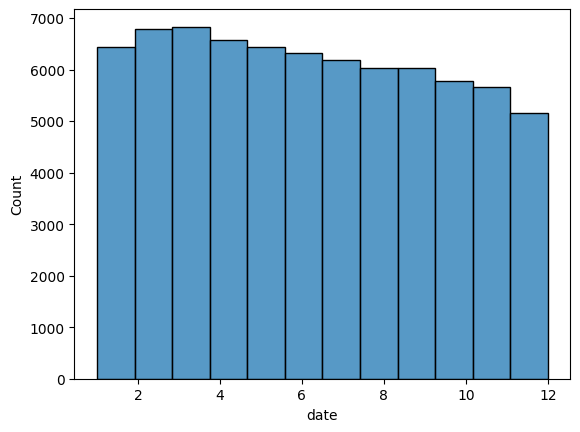

In [53]:
sns.histplot(data=modelo['date'].dt.month, bins=12)